In [88]:
import os
from typing import List
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from aeon.visualisation import plot_critical_difference, create_multi_comparison_matrix

In [89]:
RESULT_PATH = "../results/test"
_AGGREGATION = 'micro'
_THRESHOLD = 0.9
PRECISION = f'P-{_AGGREGATION}@{_THRESHOLD}'
RECALL = f'R-{_AGGREGATION}@{_THRESHOLD}'
F1 = f'F1-{_AGGREGATION}@{_THRESHOLD}'
TSMD_METHOD = 'LoCoMotif'
ALL_MODELS = ["EMD*", "LAMA", "MMotifs", "SubTSMD"]
ALL_BASELINES = ALL_MODELS + ["GrammarVizRePair", "LatentMotifs", "LoCoMotif", "Motiflets","SetFinder"]
SELECT_KWARGS = {'metric': 'Precision', 'threshold': 0.5, 'percentage': 0.15, 'min_nb_detectors': 1}

In [90]:
def load(name: str, models: List[str] = None) -> pd.DataFrame:
    models = models or ALL_MODELS
    df = pd.read_csv(f'{RESULT_PATH}/{name}.csv')
    df['model'] = df['model'].replace(TSMD_METHOD, 'SubTSMD')
    df['model'] = df['model'].replace('EMD_star', 'EMD*')
    df = df[df['model'].isin(models)]
    df = df.rename(columns={PRECISION: 'Precision', RECALL: 'Recall', F1: 'F1'})
    return df[['benchmark_set', 'ds_name', 'time_series_id', 'model', 'Precision', 'Recall', 'F1']]

In [91]:
def is_valid(df: pd.DataFrame, metric: str, threshold: float, percentage: float, min_nb_detectors: int) -> bool:
    return bool(sum([
        (group[metric] > threshold).mean() > percentage
        for _, group in df[['model', metric]].groupby(['model'])
    ]) >= min_nb_detectors)

### Critical difference diagrams

C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


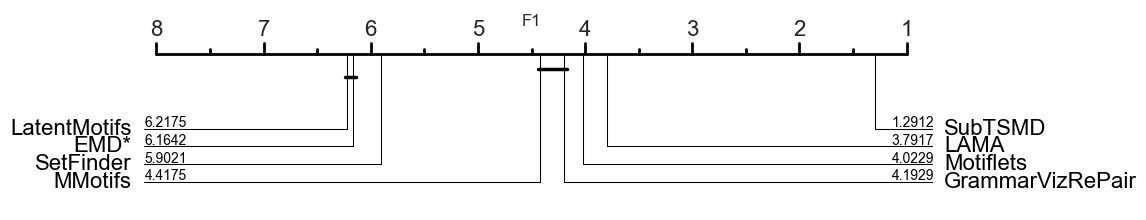

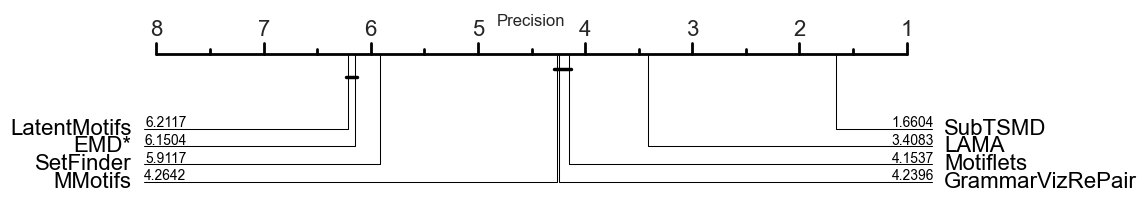

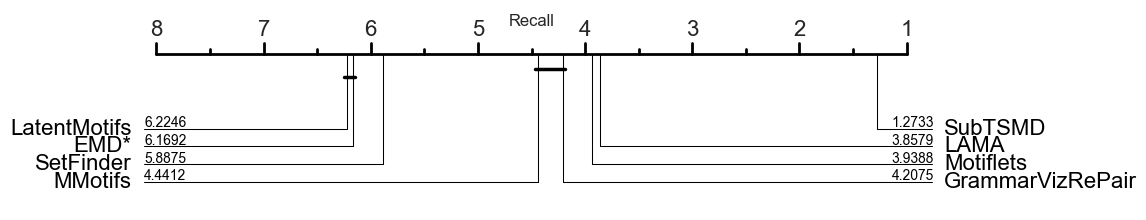

In [92]:
"""
Changed fontsizes of aeon.plot_critical_difference:
- size of ranking-axis labels set to 16 (line 309, originally was 11)
- spacing of ranks on left side to -0.12 (line 336, originally was -0.3)
- spacing of ranks on right side to 0.24 (line 399, originally was 0.4)
"""
def critical_difference_diagram(datasets: List[str], metric: str, models: List[str] = None, figsize=(10, 2), alpha: float = 0.05, select_kwargs: dict = None) -> plt.Figure:
    dfs = [load(dataset, models) for dataset in datasets]
    if select_kwargs:
        original_len_dfs = len(dfs)
        dfs = [df for df in dfs if is_valid(df, **select_kwargs)]
        if len(dfs) < original_len_dfs:
            print(f'Results are filtered, only {len(dfs)} out of {original_len_dfs} remain')
            if len(dfs) == 0:
                print('No valid datasets remain after filtering!')
                return
            
    df = pd.concat(dfs) 
    df = df.pivot(columns='model', index=['time_series_id', 'ds_name'], values=metric)
    fig, ax, *_ = plot_critical_difference(df.values, labels=df.columns, alpha=alpha, width=figsize[0], textspace=2)    
    fig.set_size_inches(*figsize)
    fig.suptitle(metric)

    return fig

for m in ['F1', 'Precision', 'Recall']:
    critical_difference_diagram(
        datasets=[f'synthetic/s{i+1}' for i in range(6)],
        metric=m,
        models=ALL_BASELINES
    )

C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


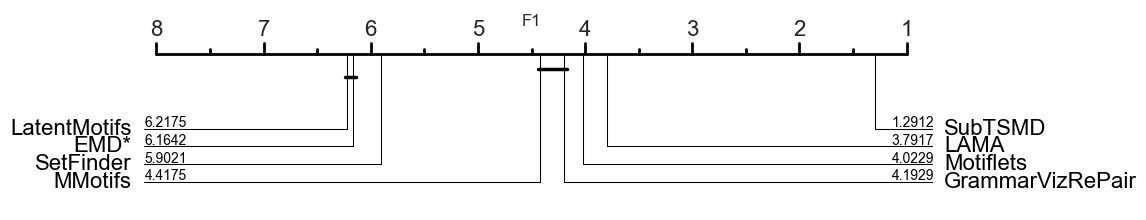

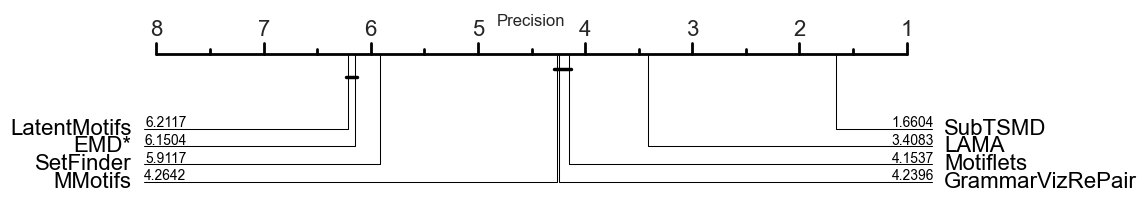

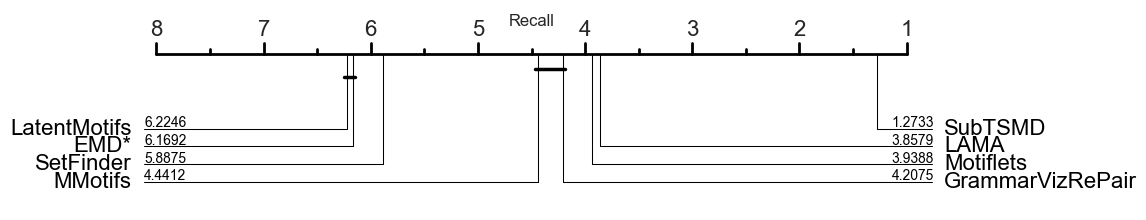

In [93]:
for m in ['F1', 'Precision', 'Recall']:
    critical_difference_diagram(
        datasets=[f'synthetic/s{i+1}' for i in range(6)],
        metric=m,
        models=ALL_BASELINES
    )

C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


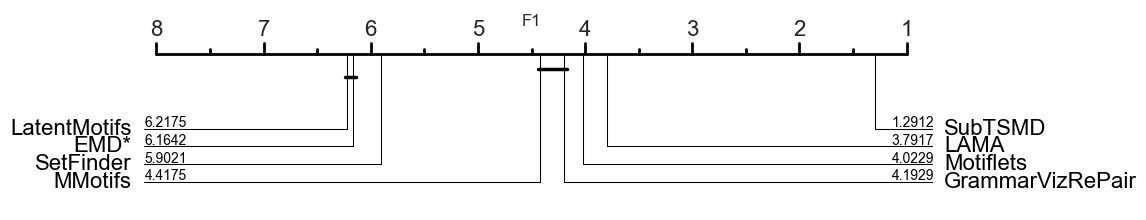

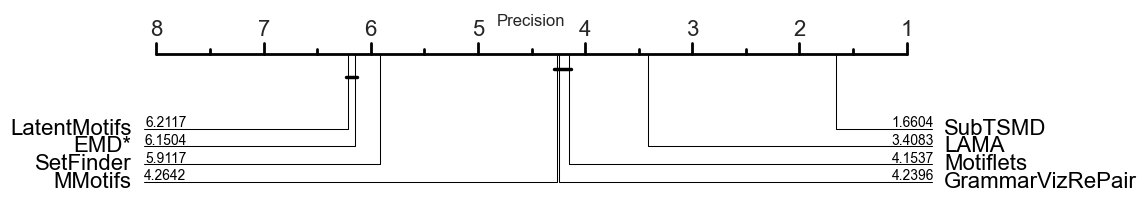

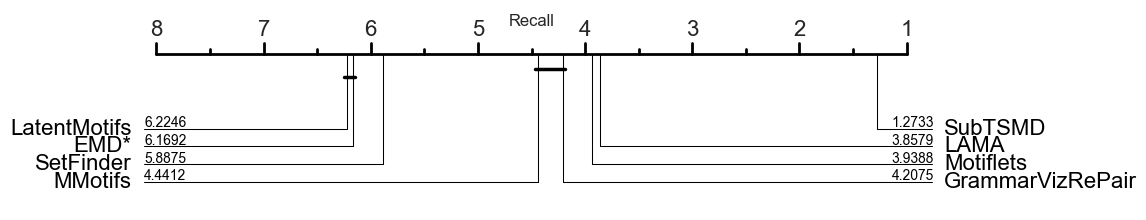

In [94]:
for m in ['F1', 'Precision', 'Recall']:
    critical_difference_diagram(
        datasets=[f'synthetic/s{i+1}' for i in range(6)],
        metric=m,
        models=ALL_BASELINES
    )

C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


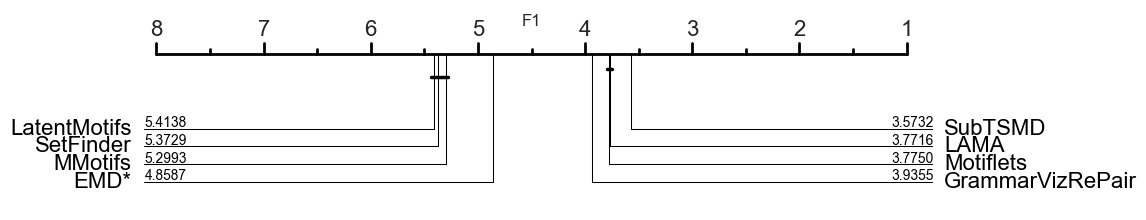

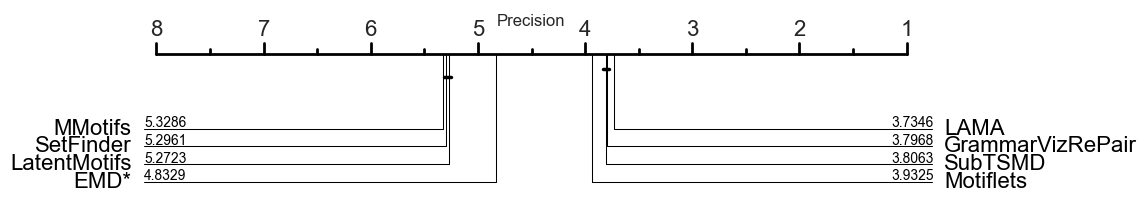

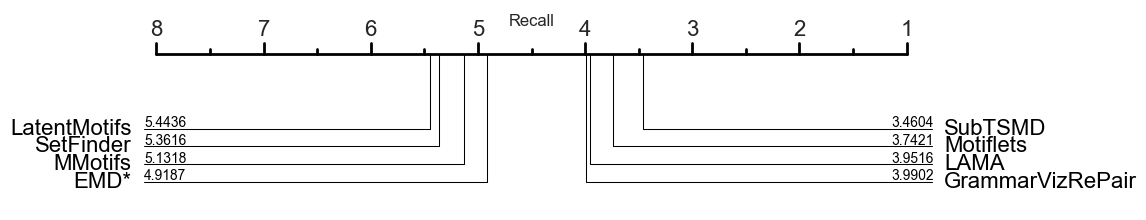

In [95]:
for m in ['F1', 'Precision', 'Recall']:
    critical_difference_diagram(
        datasets=[f'sub-tsmd-bench/{f[:-len(".csv")]}' for f in os.listdir(f'{RESULT_PATH}/sub-tsmd-bench')],
        metric=m,
        models=ALL_BASELINES
    )

Results are filtered, only 7 out of 14 remain
Results are filtered, only 7 out of 14 remain
Results are filtered, only 7 out of 14 remain


C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


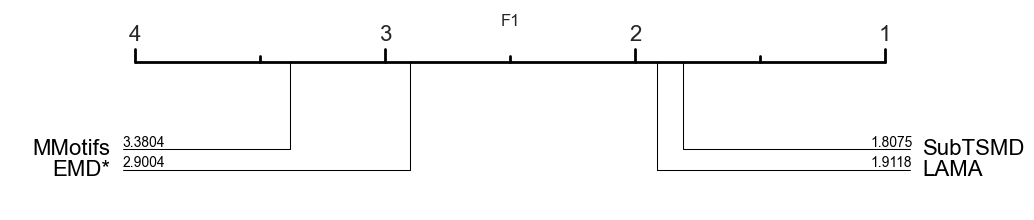

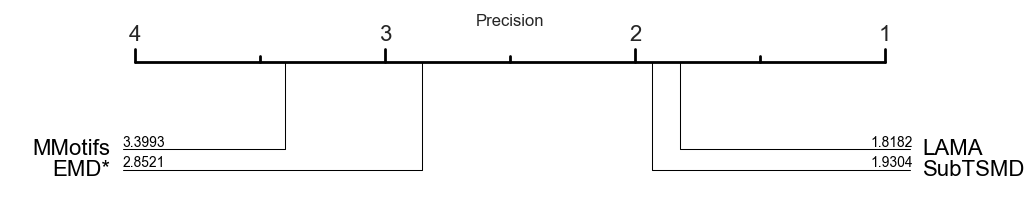

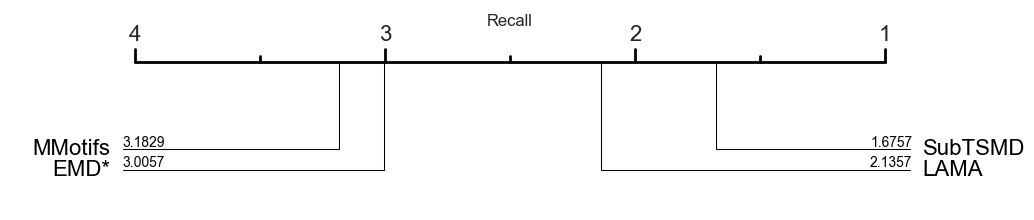

In [96]:
for m in ['F1', 'Precision', 'Recall']:
    critical_difference_diagram(
        datasets=[f'sub-tsmd-bench/{f[:-len(".csv")]}' for f in os.listdir(f'{RESULT_PATH}/sub-tsmd-bench')],
        metric=m,
        select_kwargs=SELECT_KWARGS,
    )

C:\Users\louis\AppData\Local\Temp\ipykernel_34664\2528445109.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(f'figures/fig-CD-{m}-synthetic.png', bbox_inches='tight')
C:\Users\louis\AppData\Local\Temp\ipykernel_34664\2528445109.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(f'figures/fig-CD-{m}-sub-tsmd-bench.png', bbox_inches='tight')


Results are filtered, only 7 out of 14 remain


C:\Users\louis\AppData\Local\Temp\ipykernel_34664\2528445109.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(f'figures/fig-CD-{m}-synthetic.png', bbox_inches='tight')


Results are filtered, only 7 out of 14 remain


C:\Users\louis\AppData\Local\Temp\ipykernel_34664\2528445109.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(f'figures/fig-CD-{m}-sub-tsmd-bench.png', bbox_inches='tight')
C:\Users\louis\AppData\Local\Temp\ipykernel_34664\2528445109.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(f'figures/fig-CD-{m}-synthetic.png', bbox_inches='tight')


Results are filtered, only 7 out of 14 remain


C:\Users\louis\AppData\Local\Temp\ipykernel_34664\2528445109.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(f'figures/fig-CD-{m}-sub-tsmd-bench.png', bbox_inches='tight')
C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
C:\Users\louis\PycharmProjects\subspace-motif-discovery\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


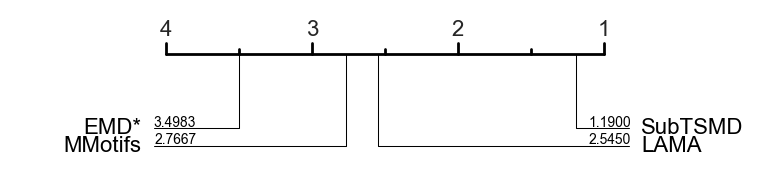

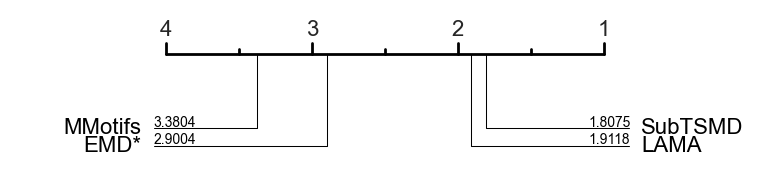

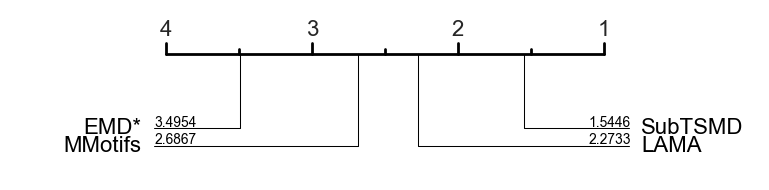

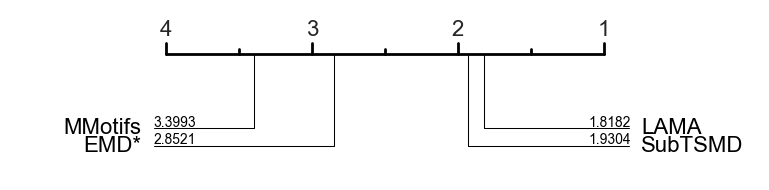

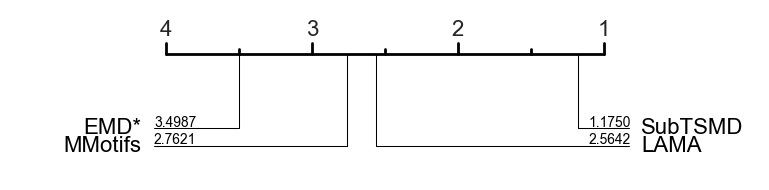

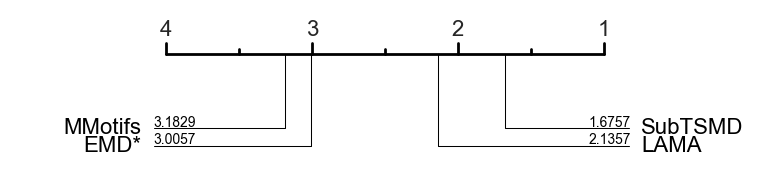

In [114]:
for m in ['F1', 'Precision', 'Recall']:
    fig = critical_difference_diagram(
        datasets=[f'synthetic/s{i+1}' for i in range(6)],
        metric=m,
        select_kwargs=SELECT_KWARGS,
        figsize=(7.5, 1.7)
    )
    fig.suptitle("")
    fig.savefig(f'figures/fig-CD-{m}-synthetic.png', bbox_inches='tight')

    fig = critical_difference_diagram(
        datasets=[f'sub-tsmd-bench/{f[:-len(".csv")]}' for f in os.listdir(f'{RESULT_PATH}/sub-tsmd-bench')],
        metric=m,
        select_kwargs=SELECT_KWARGS,
        figsize=(7.5, 1.7)
    )
    fig.suptitle("")
    fig.savefig(f'figures/fig-CD-{m}-sub-tsmd-bench.png', bbox_inches='tight')

### Multi-comparison matrix

Results are filtered, only 7 out of 14 remain
Results are filtered, only 7 out of 14 remain
Results are filtered, only 7 out of 14 remain


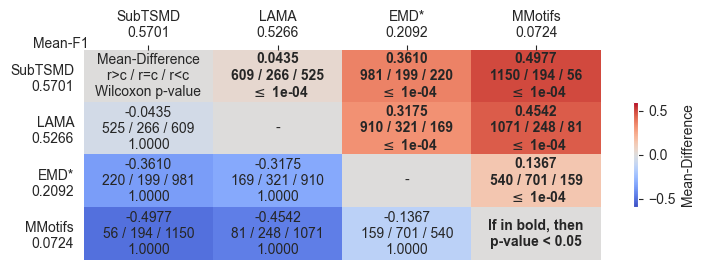

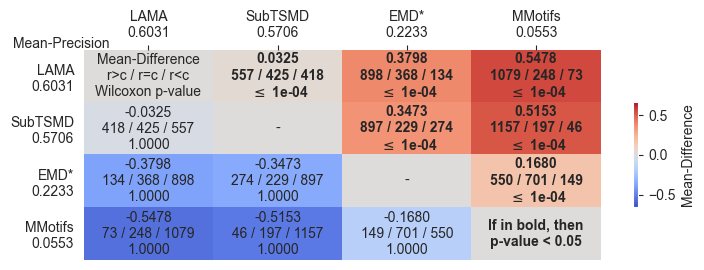

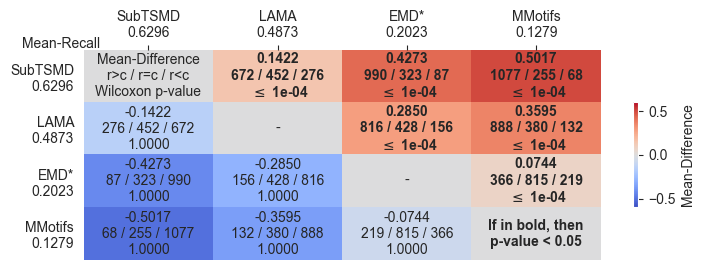

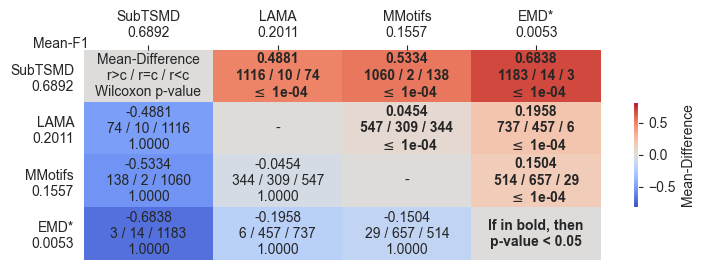

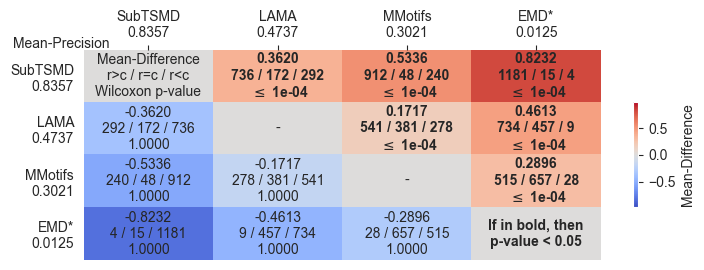

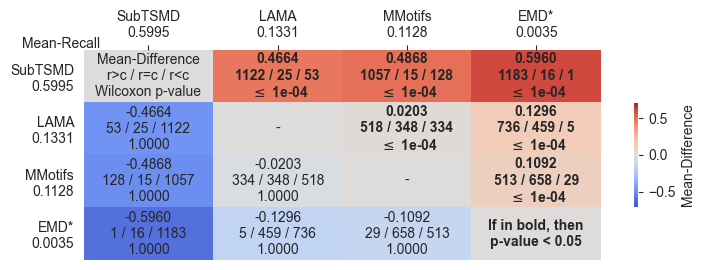

In [109]:
def mcm_plot(datasets: List[str], metric: str, models: List[str] = None, figsize=(7.5, 2.8), select_kwargs: dict = None) -> plt.Figure:
    dfs = [load(dataset, models) for dataset in datasets]
    if select_kwargs:
        original_len_dfs = len(dfs)
        dfs = [df for df in dfs if is_valid(df, **select_kwargs)]
        if len(dfs) < original_len_dfs:
            print(f'Results are filtered, only {len(dfs)} out of {original_len_dfs} remain')
            if len(dfs) == 0:
                print('No valid datasets remain after filtering!')
                return
            
    df = pd.concat(dfs) 
    df = df.pivot(columns='model', index=['time_series_id', 'ds_name'], values=metric)
    create_multi_comparison_matrix(df, used_statistic=metric, fig_size=figsize)
    plt.savefig(f'figures/fig-MCM-{metric}-{datasets[0].split("/")[0]}.png', bbox_inches='tight')
    
    
for m in ['F1', 'Precision', 'Recall']:
    mcm_plot(
        datasets=[f'sub-tsmd-bench/{f[:-len(".csv")]}' for f in os.listdir(f'{RESULT_PATH}/sub-tsmd-bench')],
        metric=m,
        select_kwargs=SELECT_KWARGS,
    )
    
for m in ['F1', 'Precision', 'Recall']:
    mcm_plot(
        datasets=[f'synthetic/s{i+1}' for i in range(6)],
        metric=m,
        select_kwargs=SELECT_KWARGS,
    )

### Raw scores

In [100]:
def raw_scores(datasets: List[str], metric: str,  models: List[str] = None, figsize=(20, 5), select_kwargs: dict = None):

    dfs = [load(dataset, models) for dataset in datasets]
    if select_kwargs:
        original_len_dfs = len(dfs)
        dfs = [df for df in dfs if is_valid(df, **select_kwargs)]
        if len(dfs) < original_len_dfs:
            print(f'Results are filtered, only {len(dfs)} out of {original_len_dfs} remain')
            if len(dfs) == 0:
                print('No valid datasets remain after filtering!')
                return     
            
    df = pd.concat(dfs) 
    fig = plt.figure(figsize=figsize)
    ax = sns.boxplot(df, x='ds_name', y=metric, hue='model')
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncols=4, fontsize=24)
    ax.set_xlabel("")
    ax.set_ylabel(metric, fontsize=24)
    ax.set_ylim([-0.05, 1.05])
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.tick_params(axis='both', which='major', labelsize=24)
    return fig

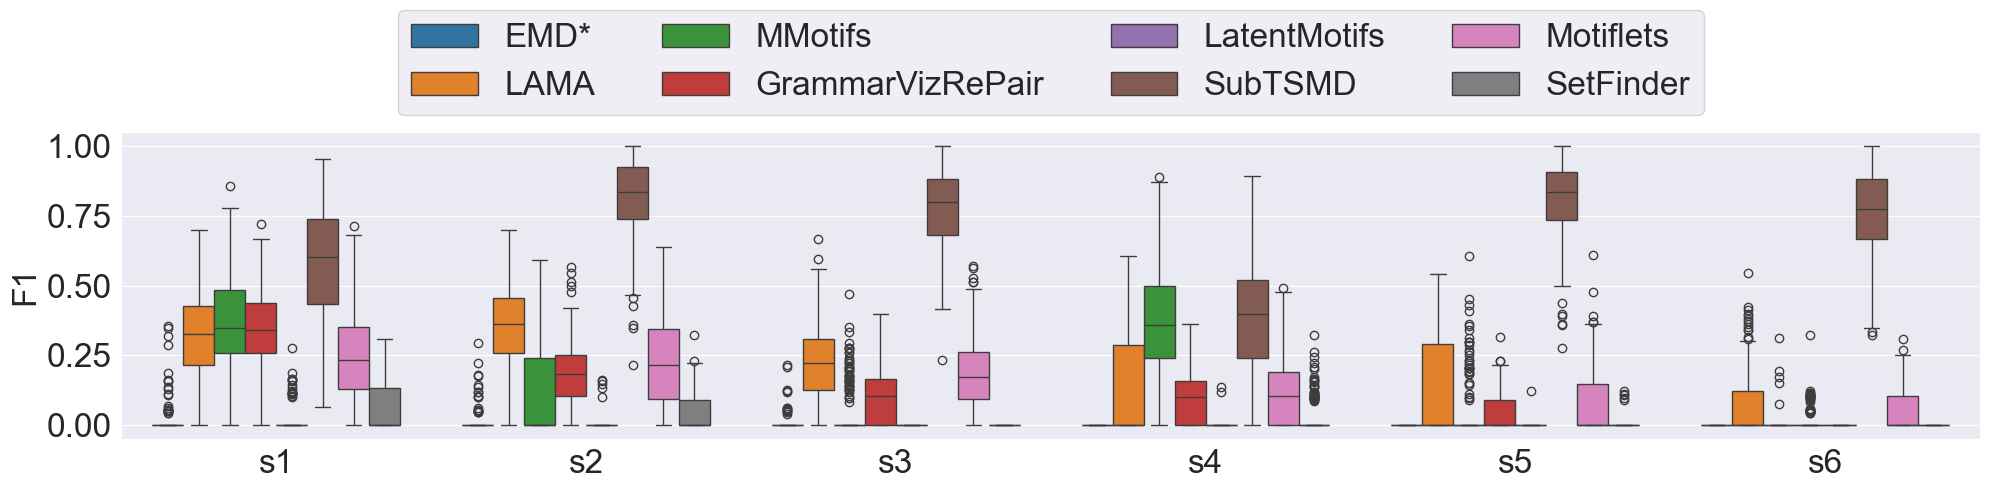

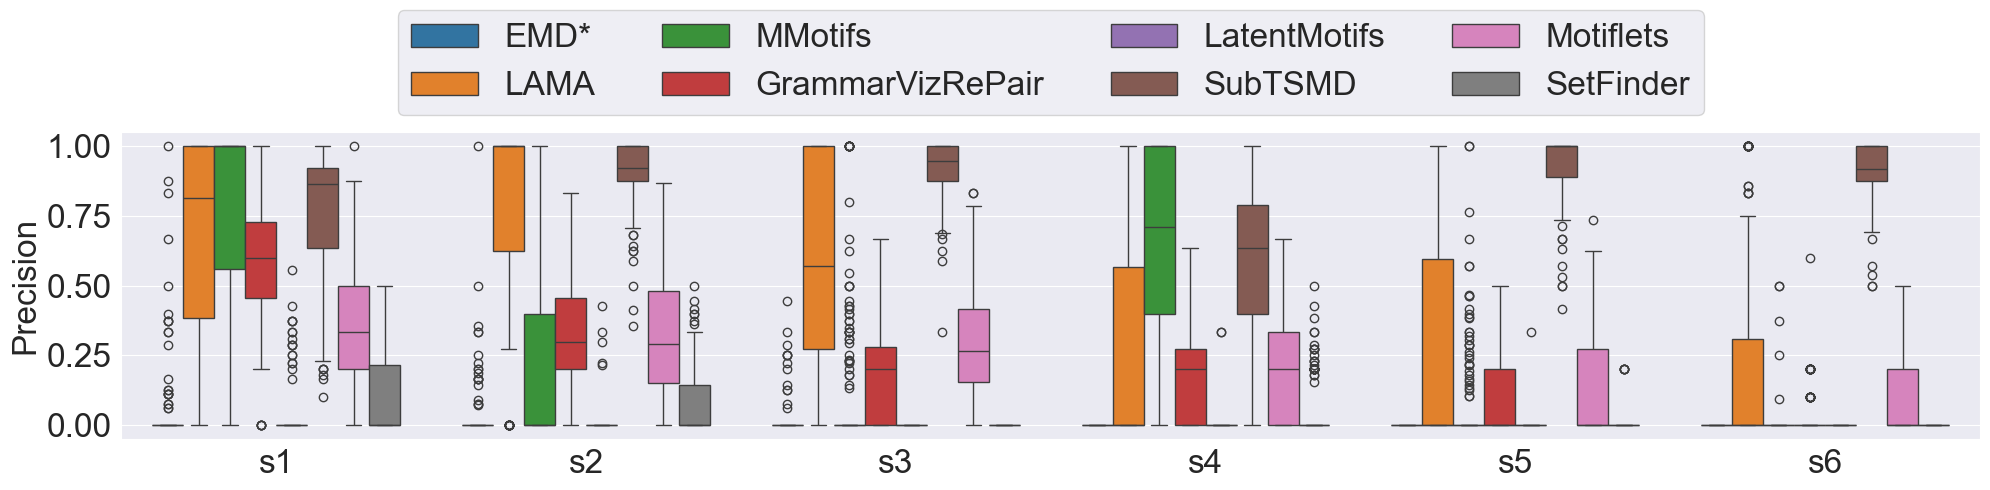

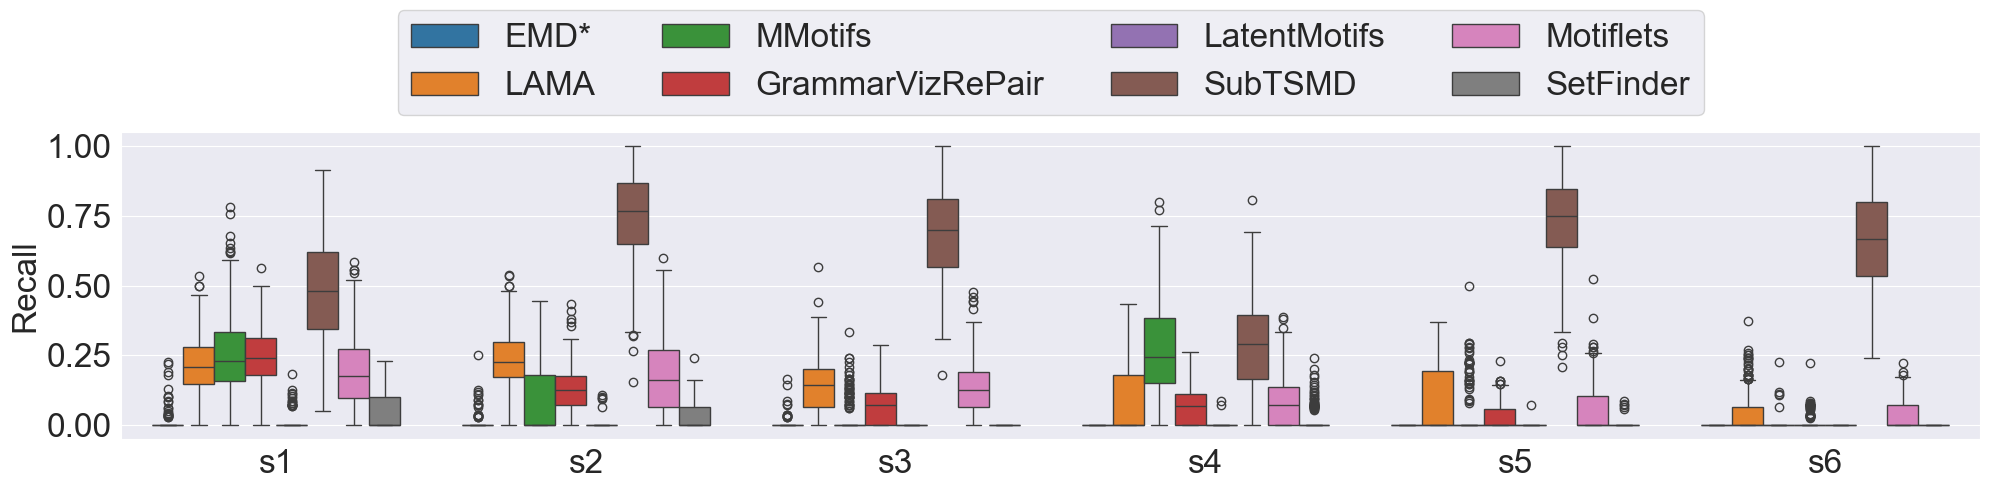

In [101]:
for m in ['F1', 'Precision', 'Recall']:
    raw_scores(
        datasets=[f'synthetic/s{i+1}' for i in range(6)],
        metric=m,        
        models=ALL_BASELINES
    )

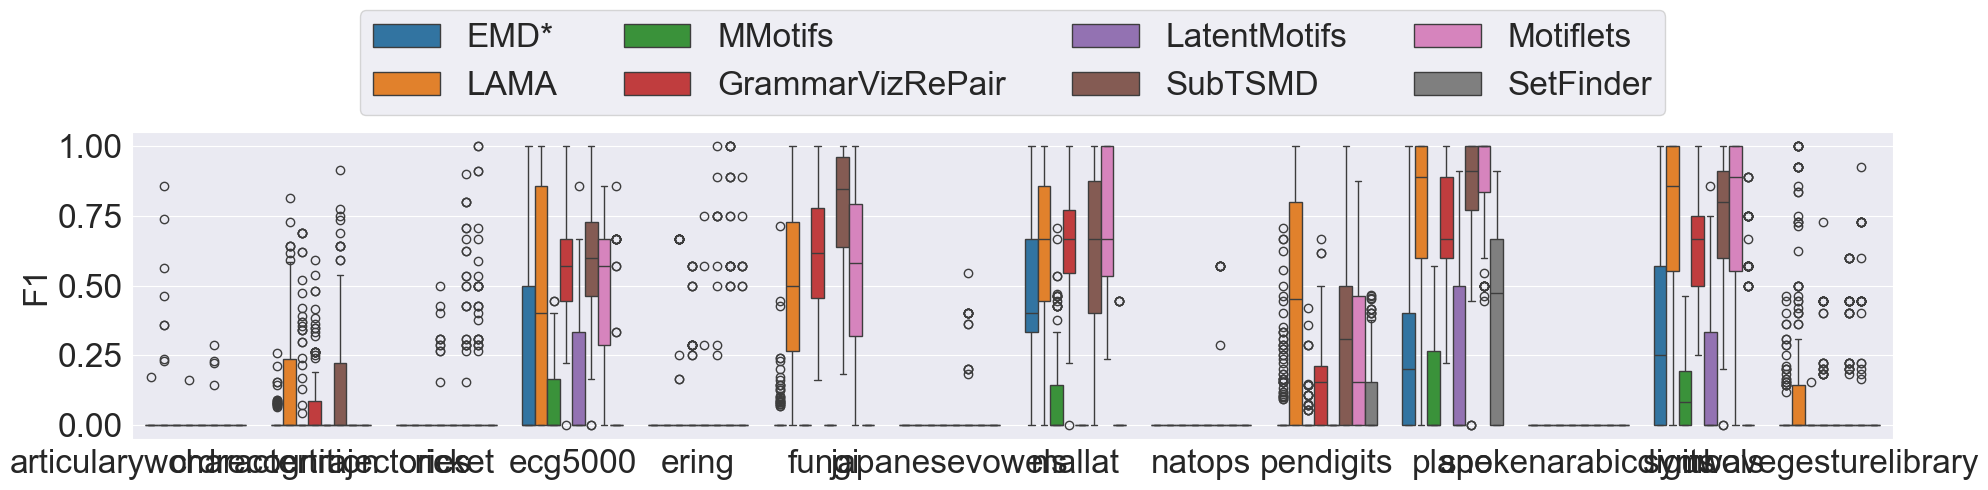

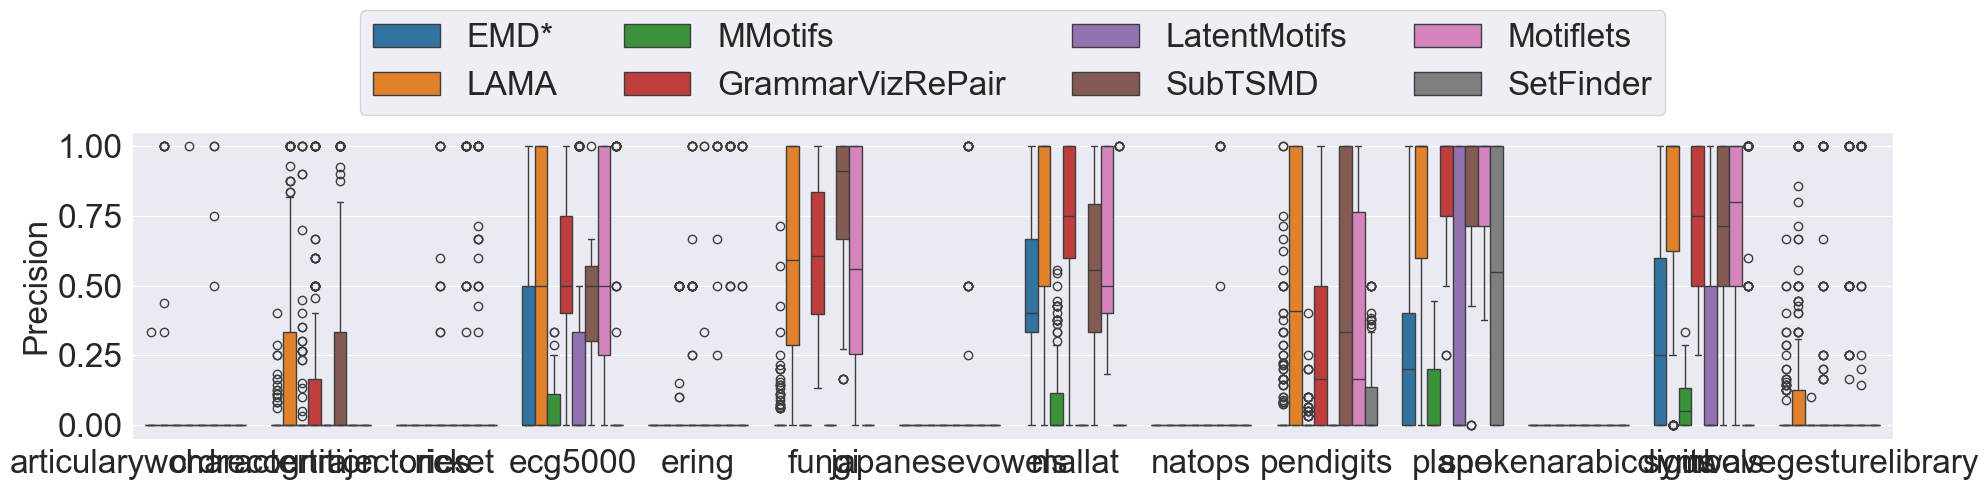

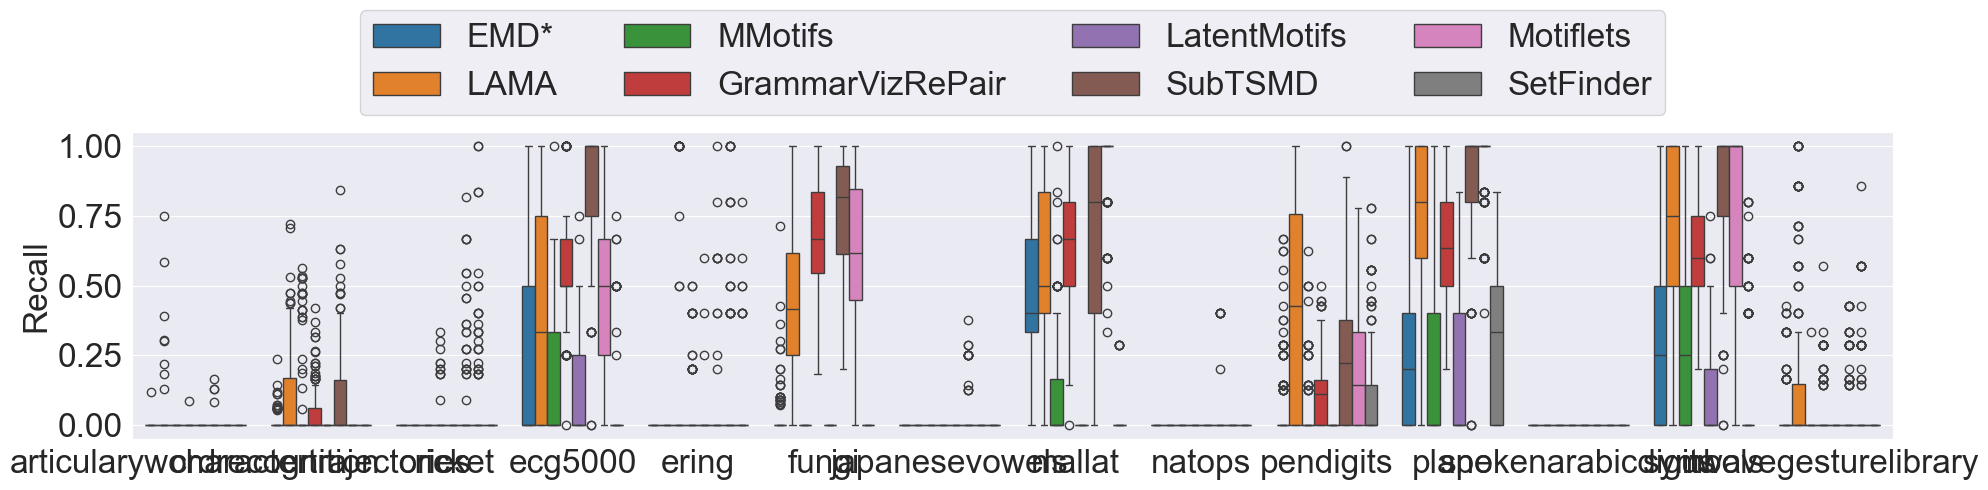

In [102]:
for m in ['F1', 'Precision', 'Recall']:
    raw_scores(
        datasets=[f'sub-tsmd-bench/{f[:-len(".csv")]}' for f in os.listdir(f'{RESULT_PATH}/sub-tsmd-bench')],
        metric=m,
        models=ALL_BASELINES
    )

Results are filtered, only 7 out of 14 remain


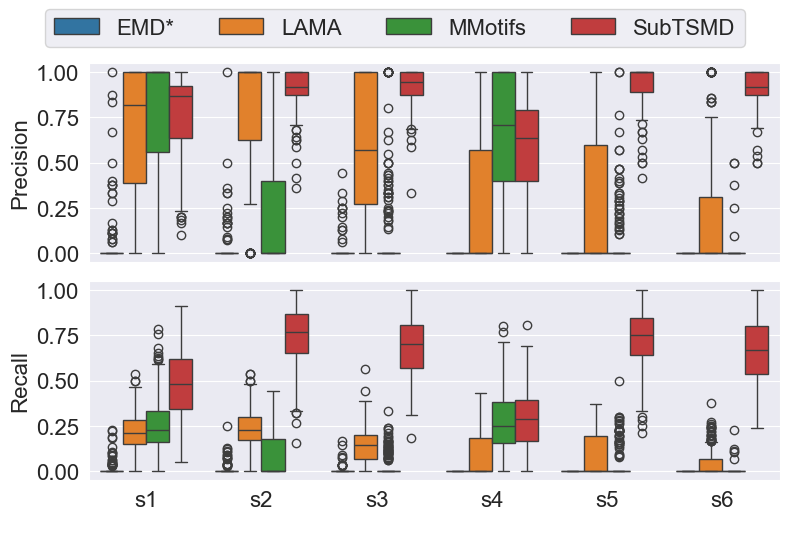

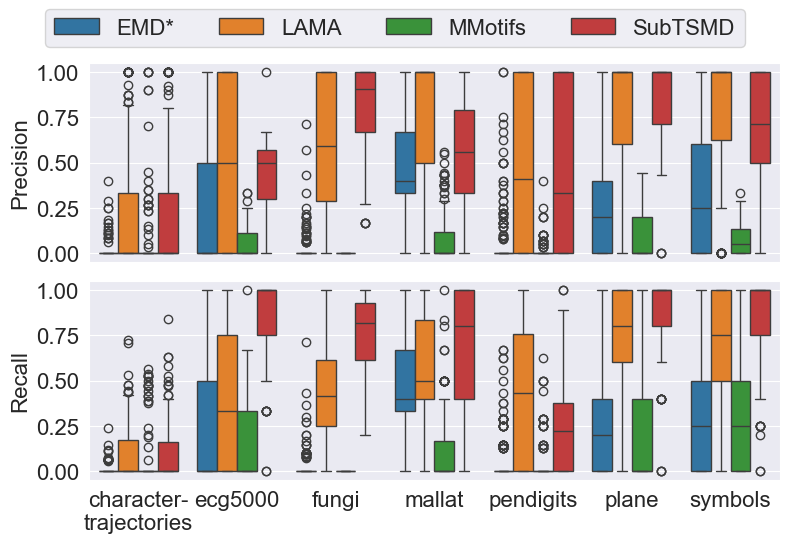

In [104]:
def raw_precision_and_recall(datasets: List[str], models: List[str] = None, figsize=(8, 5), select_kwargs: dict = None):

    dfs = [load(dataset, models) for dataset in datasets]
    if select_kwargs:
        original_len_dfs = len(dfs)
        dfs = [df for df in dfs if is_valid(df, **select_kwargs)]
        if len(dfs) < original_len_dfs:
            print(f'Results are filtered, only {len(dfs)} out of {original_len_dfs} remain')
            if len(dfs) == 0:
                print('No valid datasets remain after filtering!')
                return     
            
    df = pd.concat(dfs) 
    
    df['ds_name'] = df['ds_name'].replace({'charactertrajectories': 'character-\ntrajectories', 's1': 's1\n'})
    fig, (ax_precision, ax_recall) = plt.subplots(2, 1, figsize=figsize, sharex='all', sharey='all')
    sns.boxplot(df, x='ds_name', y='Recall', hue='model', ax=ax_recall)
    sns.boxplot(df, x='ds_name', y='Precision', hue='model', ax=ax_precision)

    for ax in (ax_recall, ax_precision):
        ax.get_legend().remove()
        ax.set_xlabel("")
        ax.set_ylabel(ax.get_ylabel(), fontsize=16)
        ax.set_ylim([-0.05, 1.05])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.tick_params(axis='both', which='major', labelsize=16)
        
    lines_labels = [ax.get_legend_handles_labels() for ax in [fig.axes[0]]]
    lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
    fig.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, 0.98), ncols=4, fontsize=16)
    fig.tight_layout()

    return fig

raw_precision_and_recall(
    datasets=[f'synthetic/s{i+1}' for i in range(6)],
    select_kwargs=SELECT_KWARGS,
).savefig('figures/fig-raw-performance-synthetic.png', bbox_inches='tight')

raw_precision_and_recall(
    datasets=[f'sub-tsmd-bench/{f[:-len(".csv")]}' for f in os.listdir(f'{RESULT_PATH}/sub-tsmd-bench')],
    select_kwargs=SELECT_KWARGS,
).savefig('figures/fig-raw-performance-sub-tsmd-bench.png', bbox_inches='tight')

### Robustness

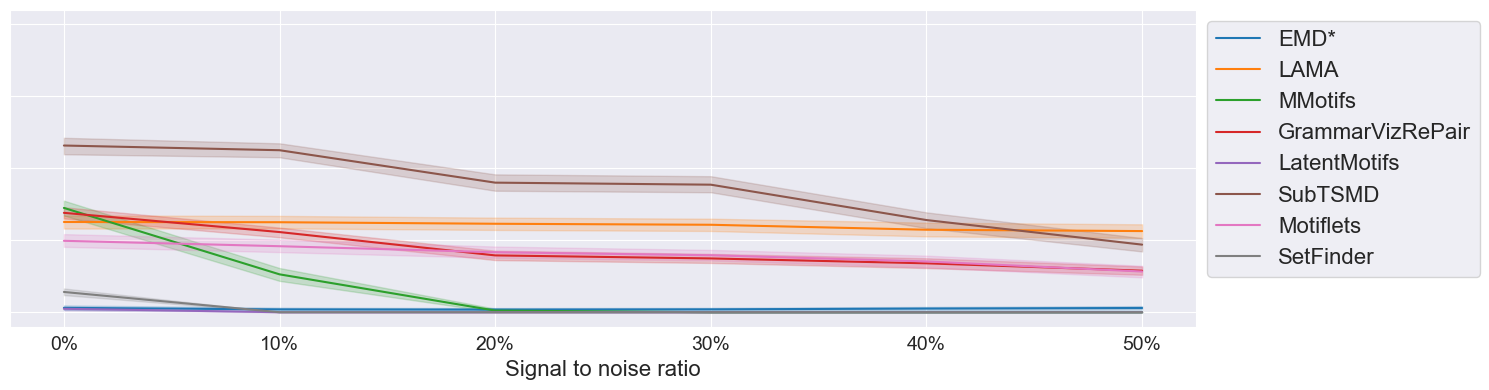

In [105]:
def robustness_to_noise(datasets: List[str], metric: str, models: List[str] = None, figsize = (20, 5)):
    dfs = [] 
    for dataset in datasets:
        df = load(dataset, models)
        df['SNR'] = 0.0 if dataset.startswith('synthetic') else float(dataset.split('#')[1].split('-')[0])
        dfs.append(df)
    df = pd.concat(dfs)
    fig = plt.figure(figsize=figsize)
    ax = sns.lineplot(data=df, x='SNR', y=metric, hue='model')
    ax.legend(loc='upper left', fontsize=16, bbox_to_anchor=(1, 1))
    ax.set_ylim([-0.05, 1.05])
    ax.set_ylabel('')
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([])
    ax.set_xlabel('Signal to noise ratio', fontsize=16)
    ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x * 100:.0f}%'))
    ax.tick_params(axis='both', which='major', labelsize=14)

    return fig


fig = robustness_to_noise(
    datasets=[f'noisy-data/s1@synthetic#{snr}-snr' for snr in [0.1, 0.2, 0.3, 0.4, 0.5]] + ['synthetic/s1'],
    metric='F1',
    models=ALL_BASELINES,
    figsize=(15, 4)
)

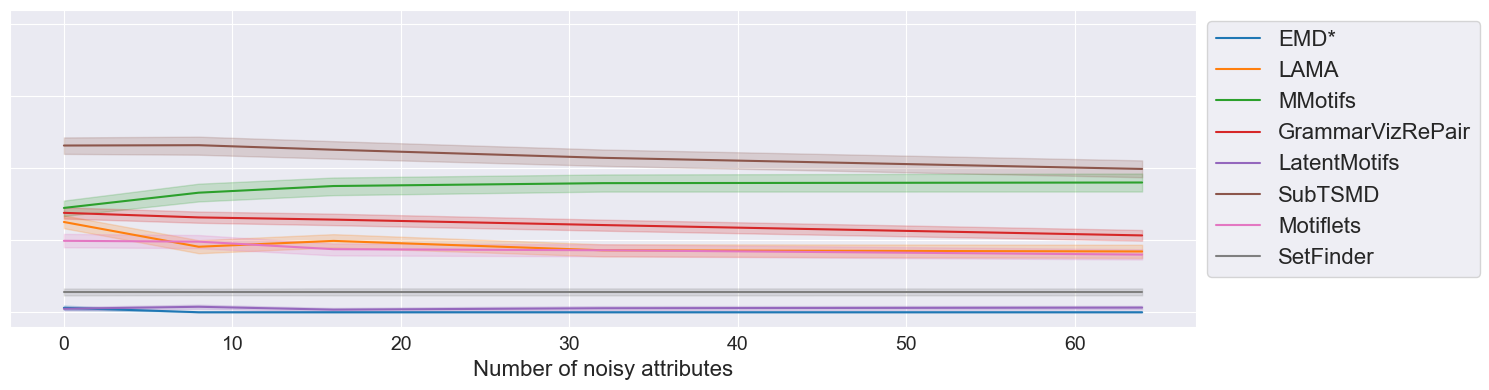

In [106]:
def robustness_to_noisy_attributes(datasets: List[str], metric: str, models: List[str] = None, figsize = (20, 5)):
    dfs = [] 
    for dataset in datasets:
        df = load(dataset, models)
        df['Number noisy attributes'] = 0 if dataset.startswith('synthetic') else int(dataset.split('#')[1].split('-')[0])
        dfs.append(df)
    df = pd.concat(dfs)
    fig = plt.figure(figsize=figsize)
    ax = sns.lineplot(data=df, x='Number noisy attributes', y=metric, hue='model') 
    ax.legend(loc='upper left', fontsize=16, bbox_to_anchor=(1, 1))
    ax.set_ylim([-0.05, 1.05])
    ax.set_ylabel('')
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([])
    ax.set_xlabel('Number of noisy attributes', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    return fig

fig = robustness_to_noisy_attributes(
    datasets=[f'noisy-attributes/s1@synthetic#{n}-noisy' for n in [8, 16, 32, 64]] + ['synthetic/s1'],
    metric='F1',
    models=ALL_BASELINES,
    figsize=(15, 4)
)

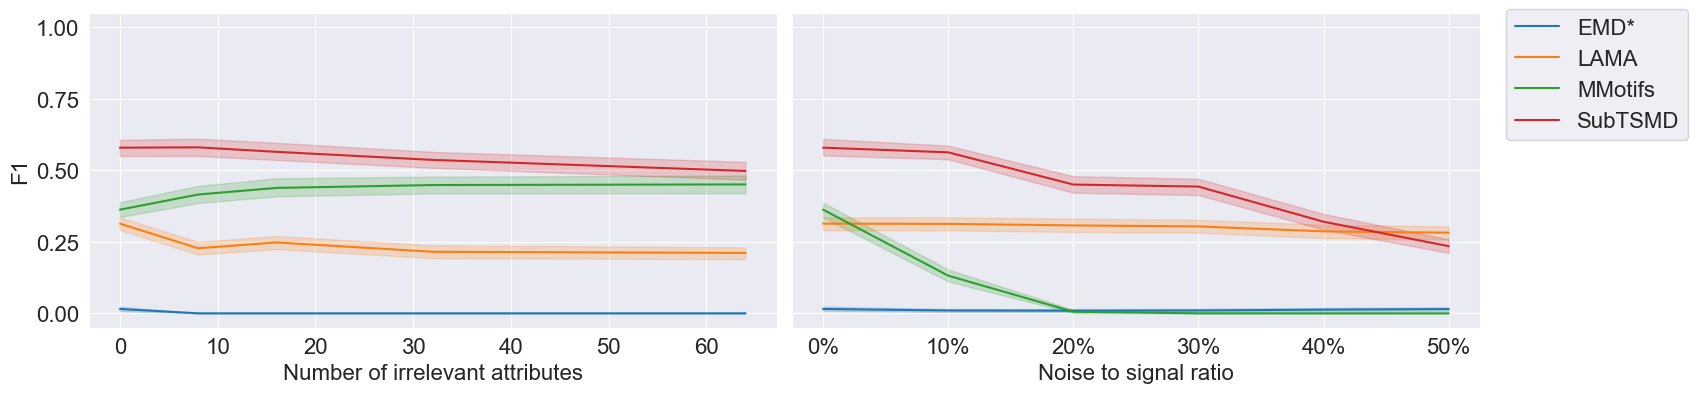

In [107]:
def robustness_noise(metric: str, figsize = (20, 5)):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey='all')

    dfs = [] 
    for dataset in [f'noisy-attributes/s1@synthetic#{n}-noisy' for n in [8, 16, 32, 64]] + ['synthetic/s1']:
        df = load(dataset)
        df['Number noisy attributes'] = 0 if dataset.startswith('synthetic') else int(dataset.split('#')[1].split('-')[0])
        dfs.append(df)
    df = pd.concat(dfs)
    sns.lineplot(data=df, x='Number noisy attributes', y=metric, hue='model', ax=ax1) 
    ax1.get_legend().remove()
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_ylabel(metric, fontsize=16)
    ax1.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax1.set_xlabel('Number of irrelevant attributes', fontsize=16)
    ax1.tick_params(axis='both', which='major', labelsize=16)
    
    dfs = [] 
    for dataset in [f'noisy-data/s1@synthetic#{snr}-snr' for snr in [0.1, 0.2, 0.3, 0.4, 0.5]] + ['synthetic/s1']:
        df = load(dataset)
        df['SNR'] = 0.0 if dataset.startswith('synthetic') else float(dataset.split('#')[1].split('-')[0])
        dfs.append(df)
    df = pd.concat(dfs)
    sns.lineplot(data=df, x='SNR', y=metric, hue='model', ax=ax2)
    ax2.get_legend().remove()
    ax2.set_ylim([-0.05, 1.05])
    ax2.set_ylabel('')
    ax2.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax2.set_xlabel('Noise to signal ratio', fontsize=16)
    ax2.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x * 100:.0f}%'))
    ax2.tick_params(axis='both', which='major', labelsize=16)
    
    lines_labels = [ax.get_legend_handles_labels() for ax in [fig.axes[0]]]
    lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
    fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=16)
    
    fig.tight_layout()
    
    return fig


robustness_noise(
    metric='F1',
    figsize=(15, 4)
).savefig('figures/fig-robustness-noise.png', bbox_inches='tight');